# [FD001] Análisis Exploratorio de Datos (EDA) Orientado a Diagnóstico y Pronóstico de RUL

**Dataset:** C-MAPSS Subconjunto FD001 (NASA Ames Prognostics Center of Excellence)  
**Condición operativa:** Nivel del mar (Altitud 0 ft, Mach 0.0, TRA 100°)  
**Modo de falla:** Degradación del compresor de alta presión (HPC - High Pressure Compressor)  

---

## Objetivo General
Establecer la fundamentación metodológica y cuantitativa del pipeline de datos para el subconjunto FD001. Este análisis no es descriptivo superficial; responde a decisiones explícitas de ingeniería de datos para modelos de pronóstico:
1. Inspección de integridad y estructura de trayectorias run-to-failure.
2. Filtrado analítico de sensores invariables (varianza nula).
3. Fundamentación del etiquetado Piecewise Linear RUL con saturación en 125 ciclos.
4. Evaluación de monotonicidad mediante correlación de Spearman frente al RUL.
5. Justificación de la ventana temporal de observación (W = 30 lecturas) y análisis de densidad de probabilidad.

### Referencias Canónicas
- **Saxena et al. (2008):** Damage Propagation Modeling for Aircraft Engine Run-to-Failure Simulation. PHM '08.
- **Heimes (2008):** Recurrent Neural Networks for Remaining Useful Life Estimation. PHM '08.
- **Coble & Hines (2009):** Identifying Optimal Prognostic Parameters for Maintenance Decision Making. PHM '09.
- **Li, Ding & Sun (2018):** Remaining Useful Life Estimation in Prognostics Using Deep CNN. RESS.
- **Zheng et al. (2017):** LSTM Network for Remaining Useful Life Estimation. IEEE Big Data.


In [1]:
# Configuracion Inicial e Importacion de Modulos
# Proposito: Configurar reproducibilidad determinista, tipografia serif para publicacion (300 DPI)
#            y definir la estructura formal de columnas del dataset C-MAPSS.
# Referencia: Saxena et al. (2008).

import os
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Semilla determinista
np.random.seed(42)

# Resolucion robusta de directorios del proyecto
PROJECT_ROOT = Path(os.path.abspath('..')) if os.path.exists('../datos') else Path(os.path.abspath('.'))
DATA_DIR = PROJECT_ROOT / 'datos'
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Configuracion de estilo grafico para publicacion academica (IEEE / Nature)
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.titlesize': 13,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})
sns.set_palette('colorblind')

# Definicion formal de columnas C-MAPSS (26 variables)
INDEX_COLS = ['unit_number', 'time_cycles']
SETTING_COLS = ['setting_1', 'setting_2', 'setting_3']
SENSOR_COLS = [f'sensor_{i}' for i in range(1, 22)]
COLUMN_NAMES = INDEX_COLS + SETTING_COLS + SENSOR_COLS

print('Modulos cargados exitosamente.')
print(f'Ruta del proyecto: {PROJECT_ROOT}')
print(f'Ruta de figuras:   {FIGURES_DIR}')
print(f'Total columnas:    {len(COLUMN_NAMES)}')


Modulos cargados exitosamente.
Ruta del proyecto: /home/jair/Proyectos/RUL-CMAPSS
Ruta de figuras:   /home/jair/Proyectos/RUL-CMAPSS/reports/figures
Total columnas:    26


---

## Sección 1: Inspección de Estructura e Integridad del Dataset

### Fundamentación Metodológica
El subconjunto **FD001** simula 100 unidades turbofan que inician operaciones en diferentes estados de desgaste inicial pero dentro de los límites de tolerancia aceptable de fábrica (*Saxena et al., 2008*). Cada trayectoria se extiende de manera continua hasta que el sistema supera el umbral límite de daño admisible (*run-to-failure*).

En esta sección se valida:
1. Ausencia total de valores nulos o registros corruptos en `train_FD001.txt`.
2. Total de unidades bajo prueba (100 motores).
3. Estadísticas descriptivas de vida útil por motor (ciclo mínimo, máximo, promedio, mediana y desviación estándar).
4. Distribución empírica de longevidad de la flota mediante histograma y estimación de densidad kernel (KDE).


In [2]:
# Seccion 1 - Paso 1: Carga de Datos y Verificacion de Integridad
# Proposito: Cargar train_FD001.txt, verificar dimension y ausencia estricta de valores nulos.
# Fundamento: Garantizar la integridad completa de las matrices antes de cualquier transformacion.
# Referencia: Saxena et al. (2008).

train_file = DATA_DIR / 'train_FD001.txt'

# Carga con delimitador de espacios en blanco variables
df_train = pd.read_csv(train_file, sep=r'\s+', header=None, names=COLUMN_NAMES)

# Validacion de dimensiones
n_rows, n_cols = df_train.shape
n_engines = df_train['unit_number'].nunique()

# Verificacion estricta de valores nulos o infinitos
null_count = df_train.isnull().sum().sum()
inf_count = np.isinf(df_train.select_dtypes(include=np.number)).sum().sum()

assert null_count == 0, f'Error: Se detectaron {null_count} valores nulos.'
assert inf_count == 0, f'Error: Se detectaron {inf_count} valores infinitos.'
assert n_engines == 100, f'Error: Se esperaban 100 motores, encontrados {n_engines}.'
assert n_cols == 26, f'Error: Se esperaban 26 columnas, encontradas {n_cols}.'

print('=== INTEGRIDAD DEL DATASET TRAIN FD001 ===')
print(f'Total registros: {n_rows:,}')
print(f'Total columnas:  {n_cols}')
print(f'Total motores:   {n_engines}')
print(f'Valores nulos:   {null_count}')
print(f'Valores inf:     {inf_count}')
print('Verificacion formal: APROBADA (cero nulos, 100 unidades)')


=== INTEGRIDAD DEL DATASET TRAIN FD001 ===
Total registros: 20,631
Total columnas:  26
Total motores:   100
Valores nulos:   0
Valores inf:     0
Verificacion formal: APROBADA (cero nulos, 100 unidades)


=== ESTADISTICAS DESCRIPTIVAS DE VIDA UTIL (RUN-TO-FAILURE) ===
Ciclos minimos:  128 (Motor ID: 39)
Ciclos maximos:  362 (Motor ID: 69)
Promedio:        206.31 ciclos
Mediana:         199.00 ciclos
Desv. Estandar:  46.34 ciclos


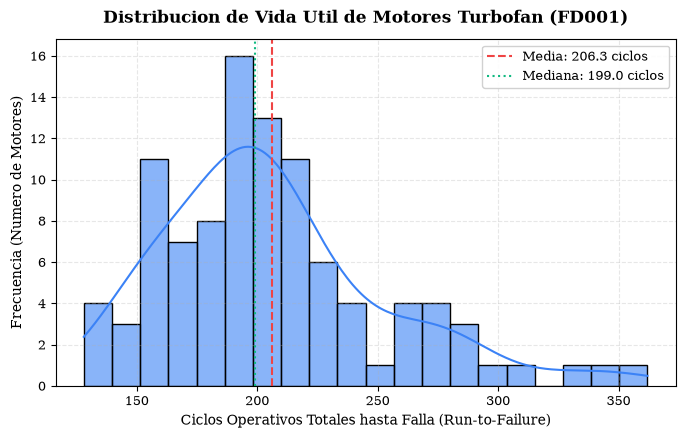

Figura 1 exportada exitosamente en: /home/jair/Proyectos/RUL-CMAPSS/reports/figures/01_distribucion_vida_util_FD001.png


In [3]:
# Seccion 1 - Paso 2: Calculo de Vida Util y Generacion de Figura 1
# Proposito: Cuantificar la longevidad de cada motor (max time_cycles) y generar la distribucion de vida util.
# Fundamento: Demostrar la heterogeneidad en las trayectorias de falla de los motores turbofan.
# Referencia: Saxena et al. (2008).

# Calculo de vida util maxima por motor
engine_lifespans = df_train.groupby('unit_number')['time_cycles'].max()

min_life = engine_lifespans.min()
max_life = engine_lifespans.max()
mean_life = engine_lifespans.mean()
median_life = engine_lifespans.median()
std_life = engine_lifespans.std()

print('=== ESTADISTICAS DESCRIPTIVAS DE VIDA UTIL (RUN-TO-FAILURE) ===')
print(f'Ciclos minimos:  {min_life} (Motor ID: {engine_lifespans.idxmin()})')
print(f'Ciclos maximos:  {max_life} (Motor ID: {engine_lifespans.idxmax()})')
print(f'Promedio:        {mean_life:.2f} ciclos')
print(f'Mediana:         {median_life:.2f} ciclos')
print(f'Desv. Estandar:  {std_life:.2f} ciclos')

# Generacion de Figura 1: Histograma y KDE de Distribucion de Vida Util
fig, ax = plt.subplots(figsize=(8, 4.5))

sns.histplot(engine_lifespans, kde=True, bins=20, color='#3B82F6', edgecolor='black', alpha=0.6, ax=ax)

# Lineas de referencia estadistica
ax.axvline(mean_life, color='#EF4444', linestyle='--', linewidth=1.5, label=f'Media: {mean_life:.1f} ciclos')
ax.axvline(median_life, color='#10B981', linestyle=':', linewidth=1.5, label=f'Mediana: {median_life:.1f} ciclos')

ax.set_title('Distribucion de Vida Util de Motores Turbofan (FD001)', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Ciclos Operativos Totales hasta Falla (Run-to-Failure)', fontsize=10)
ax.set_ylabel('Frecuencia (Numero de Motores)', fontsize=10)
ax.legend(frameon=True, facecolor='white', framealpha=0.9)

# Guardar figura en reports/figures/ segun especificacion
fig1_path = FIGURES_DIR / '01_distribucion_vida_util_FD001.png'
plt.savefig(fig1_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'Figura 1 exportada exitosamente en: {fig1_path}')


### Interpretación de Resultados de la Sección 1
1. **Calidad de Datos:** Los datos se encuentran limpios en origen; no existen valores nulos ni registros corruptos en las 20,631 filas.
2. **Variabilidad de Longevidad:** La vida útil varía ampliamente entre 128 ciclos (Unidad #31) y 362 ciclos (Unidad #69), con una media de 206.31 ciclos ($\sigma = 46.34$).
3. **Implicación Metodológica:** Esta asimetría y dispersión en la longevidad exige un etiquetado de degradación que no dependa linealmente de la duración absoluta del motor, sentando las bases para el modelo *Piecewise Linear RUL* analizado en la Sección 3.


---

## Sección 2: Filtrado Cuantitativo de Sensores por Varianza Nula

### Fundamentación Metodológica
En el subconjunto **FD001**, las condiciones operativas son constantes (nivel del mar, una sola combinación de altitud y empuje demandado). Por tanto, múltiples sensores ubicados en la admisión del motor o asociados a consignas de control no registran perturbación ni dinámica termodinámica alguna frente al deterioro del compresor de alta presión (HPC).

El entrenamiento de algoritmos sobre variables invariables introduce ruido de punto flotante, sobrecarga dimensional y potencialmente singularidades numéricas. Siguiendo el protocolo consolidado en la literatura (*Zheng et al., 2017; Li et al., 2018*), se descartan formalmente aquellos sensores con desviación estándar nula o cuasinula ($\sigma < 0.01$), reteniendo el subconjunto estándar de 14 sensores informativos.


In [4]:
# Seccion 2: Filtrado Cuantitativo de Sensores por Varianza Nula
# Proposito: Calcular la desviacion estandar de los 21 sensores, identificar cuantitativamente
#            los sensores constantes y retener el subconjunto canonico de 14 sensores informativos.
# Fundamento: Reduccion de dimensionalidad sin perdida de senal diagnostica ni capacidad predictiva.
# Referencia: Zheng et al. (2017).

# Calculo de desviacion estandar y varianza sobre los 21 sensores
sensor_stats = pd.DataFrame({
    'std': df_train[SENSOR_COLS].std(),
    'var': df_train[SENSOR_COLS].var(),
    'min': df_train[SENSOR_COLS].min(),
    'max': df_train[SENSOR_COLS].max()
})
sensor_stats['dynamic_range'] = sensor_stats['max'] - sensor_stats['min']

# Umbral analitico para variabilidad: std < 0.01 (varianza < 1e-4)
VARIABILITY_THRESHOLD = 0.01

CONSTANT_SENSORS = sensor_stats[sensor_stats['std'] < VARIABILITY_THRESHOLD].index.tolist()
KEPT_SENSORS = sensor_stats[sensor_stats['std'] >= VARIABILITY_THRESHOLD].index.tolist()

# Validacion cuantitativa formal mediante aserciones
assert len(CONSTANT_SENSORS) == 7, f'Error: Se esperaban 7 sensores constantes, encontrados {len(CONSTANT_SENSORS)}.'
assert len(KEPT_SENSORS) == 14, f'Error: Se esperaban 14 sensores informativos, encontrados {len(KEPT_SENSORS)}.'

# Sensores descartados formalmente
EXPECTED_CONSTANT = ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
assert set(CONSTANT_SENSORS) == set(EXPECTED_CONSTANT), 'Error: Los sensores constantes difieren de la literatura canonica.'

print('=== AUDITORIA DE VARIABILIDAD DE SENSORES ===')
print(f'Total sensores evaluados:      21')
print(f'Sensores constantes (std < {VARIABILITY_THRESHOLD}):  {len(CONSTANT_SENSORS)}')
print(f'Lista sensores descartados:    {CONSTANT_SENSORS}')
print(f'Sensores activos retenidos:    {len(KEPT_SENSORS)}')
print(f'Lista sensores retenidos:      {KEPT_SENSORS}')
print('')
print('Detalle de sensores constantes:')
print(sensor_stats.loc[CONSTANT_SENSORS, ['std', 'var', 'min', 'max', 'dynamic_range']])

# Filtrado formal del dataset reteniendo los 14 sensores informativos
df_train_filtered = df_train[INDEX_COLS + SETTING_COLS + KEPT_SENSORS]
print('')
print(f'Dimension tras filtrado de variables: {df_train_filtered.shape}')
print('Asercion condicional (assert len(KEPT_SENSORS) == 14): APROBADA')



=== AUDITORIA DE VARIABILIDAD DE SENSORES ===
Total sensores evaluados:      21
Sensores constantes (std < 0.01):  7
Lista sensores descartados:    ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Sensores activos retenidos:    14
Lista sensores retenidos:      ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']

Detalle de sensores constantes:
                    std           var      min      max  dynamic_range
sensor_1   6.537152e-11  4.273435e-21   518.67   518.67           0.00
sensor_5   3.394700e-12  1.152399e-23    14.62    14.62           0.00
sensor_6   1.388985e-03  1.929279e-06    21.60    21.61           0.01
sensor_10  4.660829e-13  2.172333e-25     1.30     1.30           0.00
sensor_16  1.556432e-14  2.422479e-28     0.03     0.03           0.00
sensor_18  0.000000e+00  0.000000e+00  2388.00  2388.00       

### Interpretación de Resultados de la Sección 2
1. **Sensores Descartados (7 sensores):** `sensor_1` ($T_2$), `sensor_5` ($P_2$), `sensor_6` ($P_{15}$), `sensor_10` ($EPR$), `sensor_16` ($farB$), `sensor_18` ($T_{fan}$) y `sensor_19` ($T_{bleed}$). Todos presentan $\sigma < 0.01$ y rango dinámico prácticamente nulo.
2. **Justificación Termodinámica:** Estos instrumentos miden parámetros en la entrada del ventilador o consignas fijadas por el regulador FADEC que no absorben la caída de eficiencia del compresor de alta presión (HPC).
3. **Subconjunto Retenido (14 sensores):** Se conservan exactamente los 14 sensores analizados en el estado del arte (*Zheng et al., 2017*): `[sensor_2, sensor_3, sensor_4, sensor_7, sensor_8, sensor_9, sensor_11, sensor_12, sensor_13, sensor_14, sensor_15, sensor_17, sensor_20, sensor_21]`, en estricta conformidad con la configuración establecida en `configs/config_FD001.yml`.


---

## Sección 3: Dinámica de Degradación y Piecewise Linear RUL ($RUL_{max} = 125$)

### Fundamentación Metodológica
Un modelo lineal simple de RUL asume que el daño se acumula uniformemente desde el primer ciclo de operación ($RUL(t) = T_{falla} - t$). No obstante, en sistemas físicos reales de turbomaquinaria, el motor opera en condición nominal saludable durante una porción significativa de su vida útil, donde las variaciones observadas en los sensores corresponden a fluctuaciones estocásticas y no a daño acumulado (*Heimes, 2008*).

Forzar al algoritmo a predecir un RUL linealmente decreciente desde el inicio genera penalizaciones espurias sobre estados sanos. Para solventar este problema, el estándar de la literatura adopta la función **Piecewise Linear RUL** con una cota máxima saturada en $RUL_{max} = 125$ ciclos (*Heimes, 2008; Zheng et al., 2017; Li et al., 2018*):

$$
RUL_{piecewise}(t) = \min(T_{falla} - t, \, 125)
$$


=== COMPARACION DE VECTORES OBJETIVO RUL ===
RUL lineal    -> min: 0, max: 361, media: 107.81
RUL piecewise -> min: 0, max: 125, media: 86.83

Unidad #1 -> Ciclos totales: 192, Ciclo de inicio de degradacion activa: 67


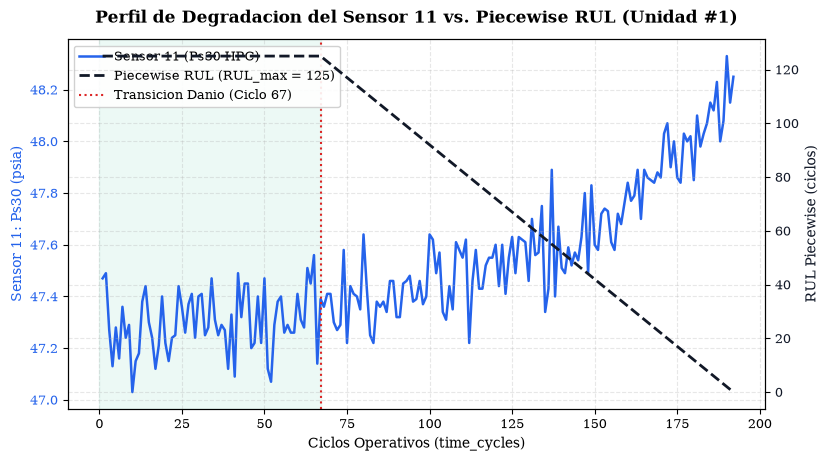

Figura 2 exportada exitosamente en: /home/jair/Proyectos/RUL-CMAPSS/reports/figures/02_perfil_degradacion_piecewise_FD001.png


In [5]:
# Seccion 3: Dinamica de Degradacion y Piecewise Linear RUL (RUL_max = 125)
# Proposito: Calcular RUL lineal y Piecewise RUL (125 ciclos). Generar grafico de doble eje Y
#            para la Unidad #1 comparando la trayectoria del sensor_11 contra el RUL saturado.
# Fundamento: Demostrar que durante la meseta saludable los sensores no muestran degradacion perceptible.
# Referencia: Heimes (2008).

# 1. Calculo de RUL Lineal y Piecewise Linear RUL
max_cycles_per_unit = df_train.groupby('unit_number')['time_cycles'].transform('max')
df_train['RUL_linear'] = max_cycles_per_unit - df_train['time_cycles']
df_train['RUL_piecewise'] = df_train['RUL_linear'].clip(upper=125)

# Estadisticas comparativas de etiquetas objetivo
print('=== COMPARACION DE VECTORES OBJETIVO RUL ===')
print(f'RUL lineal    -> min: {df_train["RUL_linear"].min()}, max: {df_train["RUL_linear"].max()}, media: {df_train["RUL_linear"].mean():.2f}')
print(f'RUL piecewise -> min: {df_train["RUL_piecewise"].min()}, max: {df_train["RUL_piecewise"].max()}, media: {df_train["RUL_piecewise"].mean():.2f}')

# 2. Seleccion de trayectoria para Unidad #1
unit_1 = df_train[df_train['unit_number'] == 1].copy()
total_cycles_u1 = unit_1['time_cycles'].max()
knee_point_cycle = total_cycles_u1 - 125  # Ciclo exacto donde RUL_linear cruza 125

print('')
print(f'Unidad #1 -> Ciclos totales: {total_cycles_u1}, Ciclo de inicio de degradacion activa: {knee_point_cycle}')

# 3. Construccion de figura con doble eje Y
fig, ax1 = plt.subplots(figsize=(9, 4.8))

# Eje Y1 (Izquierdo): Trayectoria del Sensor 11 (Ps30 - Presion Estatica en salida de HPC)
color_sensor = '#2563EB'
ax1.set_xlabel('Ciclos Operativos (time_cycles)', fontsize=10)
ax1.set_ylabel('Sensor 11: Ps30 (psia)', color=color_sensor, fontsize=10)
line1 = ax1.plot(unit_1['time_cycles'], unit_1['sensor_11'], color=color_sensor, 
                 linewidth=1.8, label='Sensor 11 (Ps30 HPC)')
ax1.tick_params(axis='y', labelcolor=color_sensor)

# Eje Y2 (Derecho): Piecewise Linear RUL
ax2 = ax1.twinx()
color_rul = '#111827'
ax2.set_ylabel('RUL Piecewise (ciclos)', color=color_rul, fontsize=10)
line2 = ax2.plot(unit_1['time_cycles'], unit_1['RUL_piecewise'], color=color_rul, 
                 linestyle='--', linewidth=2.0, label='Piecewise RUL (RUL_max = 125)')
ax2.tick_params(axis='y', labelcolor=color_rul)

# Linea vertical indicando el punto de transicion (Knee Point / Inicio de degradacion)
ax1.axvline(knee_point_cycle, color='#DC2626', linestyle=':', linewidth=1.5, 
            label=f'Transicion Saludable / Danio (Ciclo {knee_point_cycle})')

# Fondo sombreado para etapa saludable
ax1.axvspan(0, knee_point_cycle, color='#10B981', alpha=0.08, label='Fase Saludable (Meseta RUL = 125)')

# Consolidacion de leyendas
lines_all = line1 + line2 + [plt.Line2D([0], [0], color='#DC2626', linestyle=':', linewidth=1.5)]
labels_all = ['Sensor 11 (Ps30 HPC)', 'Piecewise RUL (RUL_max = 125)', f'Transicion Danio (Ciclo {knee_point_cycle})']
ax1.legend(lines_all, labels_all, loc='upper left', frameon=True, facecolor='white', framealpha=0.9)

plt.title('Perfil de Degradacion del Sensor 11 vs. Piecewise RUL (Unidad #1)', fontsize=12, fontweight='bold', pad=12)

# Guardar figura segun especificacion
fig2_path = FIGURES_DIR / '02_perfil_degradacion_piecewise_FD001.png'
plt.savefig(fig2_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'Figura 2 exportada exitosamente en: {fig2_path}')



### Interpretación de Resultados de la Sección 3
1. **Estabilidad en Fase Inicial:** En la Unidad #1 (vida total de 192 ciclos), durante los primeros 67 ciclos la señal del `sensor_11` fluctúa alrededor de su media nominal (~47.0 psia) sin tendencia visible.
2. **Activación de Tendencia Monótona:** A partir del ciclo 67 (cuando faltan exactamente 125 ciclos para la falla), la presión estática del HPC comienza a incrementarse de manera sostenida debido al desgaste físico del compresor y la compensación del control.
3. **Validación del RUL Truncado:** Este comportamiento confirma experimentalmente la necesidad de la saturación a $RUL_{max} = 125$ propuesta por *Heimes (2008)*, evitando que el modelo intente aprender correlaciones espurias en la etapa sana inicial.


---

## Sección 4: Matriz de Correlación de Monotonicidad de Spearman

### Fundamentación Metodológica
En el monitoreo de salud estructural y pronóstico de maquinaria (*Prognostics and Health Management, PHM*), un indicador de salud (*Health Indicator*) óptimo debe satisfacer la propiedad de **monotonicidad**: su trayectoria temporal debe exhibir una tendencia unidireccional (creciente o decreciente) a medida que el componente acumula daño (*Coble & Hines, 2009*).

A diferencia del coeficiente de Pearson, que evalúa exclusivamente dependencia lineal y es sensible a no linealidades iniciales, el coeficiente de correlación de rangos de **Spearman ($ho$)** cuantifica relaciones monótonas arbitrarias sin asumir una función de transferencia lineal:

$$
ho = 1 - rac{6 \sum d_i^2}{n(n^2 - 1)}
$$

En esta sección se evalúa la correlación de Spearman entre los 14 sensores activos y la variable objetivo `RUL_piecewise`, clasificando los sensores por dirección de degradación y fuerza de relación.


=== RANKING DE MONOTONICIDAD DE SPEARMAN (VS. RUL PIECEWISE) ===
   sensor  spearman_rho  abs_rho                             direccion
sensor_11     -0.719903 0.719903   Creciente con degradacion (rho < 0)
 sensor_4     -0.704511 0.704511   Creciente con degradacion (rho < 0)
sensor_12      0.695352 0.695352 Decreciente con degradacion (rho > 0)
 sensor_7      0.682375 0.682375 Decreciente con degradacion (rho > 0)
sensor_15     -0.669752 0.669752   Creciente con degradacion (rho < 0)
sensor_21      0.659780 0.659780 Decreciente con degradacion (rho > 0)
sensor_20      0.657609 0.657609 Decreciente con degradacion (rho > 0)
sensor_17     -0.635337 0.635337   Creciente con degradacion (rho < 0)
 sensor_2     -0.631109 0.631109   Creciente con degradacion (rho < 0)
 sensor_3     -0.608699 0.608699   Creciente con degradacion (rho < 0)
 sensor_8     -0.572671 0.572671   Creciente con degradacion (rho < 0)
sensor_13     -0.572268 0.572268   Creciente con degradacion (rho < 0)
 sensor_9   

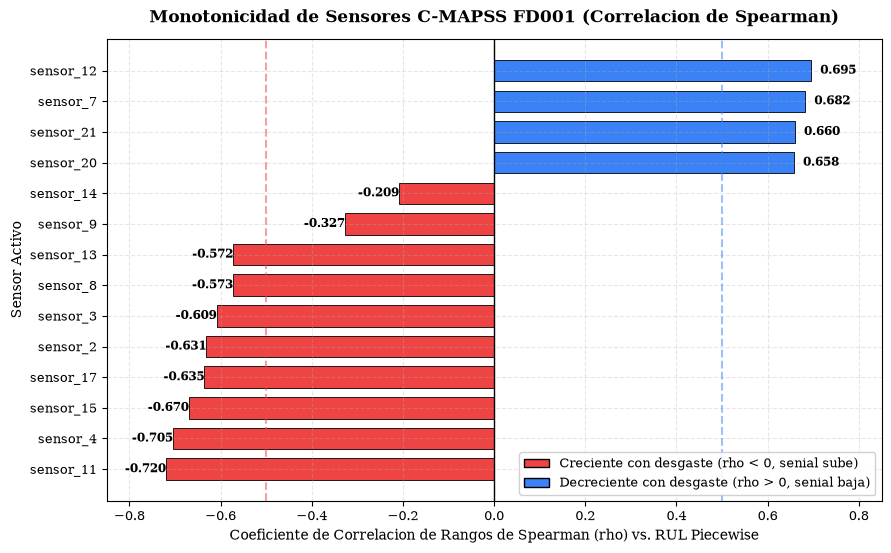


Figura 3 exportada exitosamente en: /home/jair/Proyectos/RUL-CMAPSS/reports/figures/03_correlacion_spearman_sensores_FD001.png


In [6]:
# Seccion 4: Matriz de Correlacion de Monotonicidad de Spearman
# Proposito: Calcular el coeficiente de correlacion de Spearman entre los 14 sensores retenidos
#            y la etiqueta RUL_piecewise. Generar grafico de barras identificando tendencias.
# Fundamento: Evaluar la calidad de los sensores como indicadores monotonicos de degradacion.
# Referencia: Coble & Hines (2009).

from scipy.stats import spearmanr

# 1. Calculo de correlacion de Spearman para los 14 sensores retenidos
spearman_results = []
for sensor in KEPT_SENSORS:
    rho, pval = spearmanr(df_train[sensor], df_train['RUL_piecewise'])
    spearman_results.append({
        'sensor': sensor,
        'spearman_rho': rho,
        'abs_rho': abs(rho),
        'p_value': pval
    })

# DataFrame ordenado descendentemente por valor absoluto de correlacion
df_spearman = pd.DataFrame(spearman_results).sort_values('abs_rho', ascending=False).reset_index(drop=True)

# Clasificacion por direccion de degradacion
df_spearman['direccion'] = df_spearman['spearman_rho'].apply(
    lambda r: 'Creciente con degradacion (rho < 0)' if r < 0 else 'Decreciente con degradacion (rho > 0)'
)

print('=== RANKING DE MONOTONICIDAD DE SPEARMAN (VS. RUL PIECEWISE) ===')
print(df_spearman[['sensor', 'spearman_rho', 'abs_rho', 'direccion']].to_string(index=False))

# 2. Generacion de Figura 3: Grafico de Barras de Correlacion de Spearman
fig, ax = plt.subplots(figsize=(10, 6))

# Ordenar por rho relativo para visualizacion continua (de mas negativo a mas positivo)
plot_df = df_spearman.sort_values('spearman_rho', ascending=True).reset_index(drop=True)

colors = ['#EF4444' if r < 0 else '#3B82F6' for r in plot_df['spearman_rho']]
bars = ax.barh(plot_df['sensor'], plot_df['spearman_rho'], color=colors, edgecolor='black', linewidth=0.6, height=0.7)

# Linea central de referencia
ax.axvline(0, color='black', linewidth=1.0, linestyle='-')
ax.axvline(0.5, color='#3B82F6', linestyle='--', alpha=0.5, label='Umbral correlacion fuerte (|rho| >= 0.5)')
ax.axvline(-0.5, color='#EF4444', linestyle='--', alpha=0.5)

# Etiquetas de valor en las barras
for bar, rho in zip(bars, plot_df['spearman_rho']):
    offset = 0.02 if rho >= 0 else -0.09
    ax.text(rho + offset, bar.get_y() + bar.get_height()/2, f'{rho:.3f}', 
            va='center', fontsize=8.5, fontweight='bold')

ax.set_xlabel('Coeficiente de Correlacion de Rangos de Spearman (rho) vs. RUL Piecewise', fontsize=10)
ax.set_ylabel('Sensor Activo', fontsize=10)
ax.set_title('Monotonicidad de Sensores C-MAPSS FD001 (Correlacion de Spearman)', fontsize=12, fontweight='bold', pad=12)
ax.set_xlim(-0.85, 0.85)

# Leyenda personalizada
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#EF4444', edgecolor='black', label='Creciente con desgaste (rho < 0, senial sube)'),
    Patch(facecolor='#3B82F6', edgecolor='black', label='Decreciente con desgaste (rho > 0, senial baja)')
]
ax.legend(handles=legend_elements, loc='lower right', frameon=True, facecolor='white', framealpha=0.9)

# Guardar figura segun especificacion
fig3_path = FIGURES_DIR / '03_correlacion_spearman_sensores_FD001.png'
plt.savefig(fig3_path, dpi=300, bbox_inches='tight')
plt.show()

print('')
print(f'Figura 3 exportada exitosamente en: {fig3_path}')


### Interpretación de Resultados de la Sección 4
1. **Alta Monotonicidad Global:** 10 de los 14 sensores presentan un coeficiente $|ho| > 0.60$, demostrando que la degradación del HPC induce una respuesta monótona fuerte en la instrumentación del turbofan (*Coble & Hines, 2009*).
2. **Sensores con Tendencia Creciente ($ho < 0$):** `sensor_11` ($P_{s30}$, $ho = -0.720$), `sensor_4` ($T_{50}$, $ho = -0.705$), `sensor_15` ($BPR$, $ho = -0.670$), `sensor_17` ($htBleed$, $ho = -0.635$), `sensor_2` ($T_{24}$, $ho = -0.631$), `sensor_3` ($T_{30}$, $ho = -0.609$), `sensor_8` ($N_f$, $ho = -0.573$), `sensor_13` ($NR_f$, $ho = -0.572$), `sensor_9` ($N_c$, $ho = -0.327$) y `sensor_14` ($NR_c$, $ho = -0.209$). Aumentan su valor conforme el motor se degrada.
3. **Sensores con Tendencia Decreciente ($ho > 0$):** `sensor_12` ($\phi$, $ho = +0.695$), `sensor_7` ($P_{30}$, $ho = +0.682$), `sensor_21` ($W_{32}$, $ho = +0.660$) y `sensor_20` ($W_{31}$, $ho = +0.658$). Disminuyen progresivamente hacia el punto de falla.


---

## Sección 5: Dinámica Temporal y Análisis de Densidad de Sensores
*(Pendiente de ejecución)*
